# YOLOv11 for CHINA ENERGY LABEL Detection

This notebook details the process of training a YOLO (You Only Look Once) classification model to detect CHINA energy label from images. The workflow covers every stage from environment setup and data acquisition to model training, in-depth evaluation with specialized metrics, and model explainability using Grad-CAM.

### 1. Setup Environment

We begin by setting up our Python environment. To ensure the project is organized and reproducible, we first define a `HOME` constant for our working directory. This makes all file paths relative and the notebook portable.

In [1]:
import os
HOME = os.getcwd()
print(f"Project Home Directory: {HOME}")

Project Home Directory: /content


Next, we install the necessary libraries.
- `ultralytics`: The core framework for our YOLO model.
- `kagglehub`: To easily download datasets from Kaggle.
- `grad-cam`: For model explainability.
- Other libraries like `numpy`, `opencv-python`, and `matplotlib` are standard tools for data manipulation and visualization.

In [ ]:
%pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 84.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
%pip install --no-cache-dir kagglehub==0.3.12 huggingface_hub==0.33.1 pillow numpy opencv-python==4.11.0.86 matplotlib==3.10.3 seaborn==0.13.2 pandas==2.3.0 scikit-learn==1.7.0 grad-cam==1.5.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 288.3 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 357.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 393.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 218.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 338.9 MB/s  0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=f3c1caa438c573e97e60203b694a44d37d1d4210391371a2990a65e4ba171c3e
  Stored in directory: /tmp/pip-ephem-wheel-cache-53gqrg6q/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv

In [6]:
%pip install --no-cache-dir ultralytics
%pip install -U ultralytics onnx

import ultralytics
ultralytics.checks()

from ultralytics import settings
settings.update({'runs_dir': '/content/drive/MyDrive/runs'})
print("Ultralytics runs_dir:", settings['runs_dir'])

Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Setup complete ✅ (12 CPUs, 167.1 GB RAM, 44.3/235.7 GB disk)
Ultralytics runs_dir: /content/drive/MyDrive/runs


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Convert the .pt model to .onnx model.

In [5]:
from ultralytics import YOLO
model = YOLO('/content/drive/MyDrive/runs_backup/energy_label_training_25cls/yolo_cls_25cls/weights/best.pt')
model.export(format='onnx', imgsz=224, opset=12, dynamic=False)

Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11x-cls summary (fused): 94 layers, 28,364,441 parameters, 0 gradients, 110.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/runs_backup/energy_label_training_25cls/yolo_cls_25cls/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 25) (54.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 336ms
Prepared 4 packages in 3.12s
Installed 4 packages in 299ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 4.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: s

'/content/drive/MyDrive/runs_backup/energy_label_training_25cls/yolo_cls_25cls/weights/best.onnx'

In [ ]:
import torch

DEVICE = "cpu"

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Current Device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))
    DEVICE = torch.device("cuda")
print("Using DEVICE:", DEVICE)

CUDA available: True
Current Device: 0
Device name: NVIDIA A100-SXM4-80GB
Using DEVICE: cuda


In [ ]:
# Define the path to store all the dataset files
import os

DOWNLOAD_PATH = os.path.join(HOME, "downloads")

RAW_DATASET_PATH = "/content/drive/MyDrive/dataset0318"
DATASET_PATH = RAW_DATASET_PATH

VISUALIZATION_PATH = os.path.join(HOME, "visualizations")

os.makedirs(DOWNLOAD_PATH, exist_ok=True)
os.makedirs(VISUALIZATION_PATH, exist_ok=True)

print("RAW_DATASET_PATH:", RAW_DATASET_PATH)
print("DATASET_PATH:", DATASET_PATH)
print("VISUALIZATION_PATH:", VISUALIZATION_PATH)

RAW_DATASET_PATH: /content/drive/MyDrive/dataset0318
DATASET_PATH: /content/drive/MyDrive/dataset0318
VISUALIZATION_PATH: /content/visualizations


### 2. Download Dataset (If dataset is provided, skip this step.)

We download two datasets. The primary dataset is used for training and validation, while a smaller, separate dataset is reserved for testing. Using a completely unseen test set provides a more realistic measure of the model's generalization performance.

**Datasets:**
*   [Driver Drowsiness Dataset (DDD)](https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd) (41,790 images)
*   [Driver Drowsiness Detection](https://universe.roboflow.com/tesi-jotog/driver-drowsiness-detection-7fvkf) (7,342 images)

100%|██████████| 2.58G/2.58G [00:16<00:00, 173MB/s] 

Extracting files...


100%|██████████| 14.2M/14.2M [00:00<00:00, 73.6MB/s]

Extracting files...


kaggle Datasets downloaded to: ['/workspace/downloads/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1', '/workspace/downloads/datasets/yasharjebraeily/drowsy-detection-dataset/versions/1']


Verify the structure of the downloaded files

In [ ]:
for root, dirs, files in os.walk(DOWNLOAD_PATH):
    print(f'Found folder: {root} with {len(files)} files')

NameError: name 'DOWNLOAD_PATH' is not defined

### 3. Organize Dataset

The `ultralytics` YOLO trainer expects a specific directory structure for classification tasks. We need to organize our downloaded images into `train`-70%, `val` (validation)-20%, and `test`-10% folders. Within each of these, we need subfolders named after our classes (e.g., `level1_damage`, `level1_normal`, `level2_damage`, `level2_normal`, ...).

**Required Structure:**
```
dataset/
├── train/
│   ├── level1_damage/
│   ├── level1_damage/
│   ├── level2_normal/ 
│   ├── .../
├── val/
│   ├── level1_damage/
│   ├── level1_normal/
└── test/
    ├── level1_damage/
    └── level1_normal/
```

We Organize the dataset by doing these:
1.   Split the first dataset into train and val set (while keeping their labels intact).
2.   Merge the second dataset into a single test set (while keeping their labels intact)
3.   Make sure 70% of the merged test set is used as train set, 20% is used as val set, and 10% is used as test set.



In [ ]:
import os
from collections import Counter

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def _list_classes(split_dir):
    return sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])

def _count_images_in_class_dir(class_dir):
    n = 0
    for fn in os.listdir(class_dir):
        if fn.lower().endswith(IMG_EXTS):
            n += 1
    return n

for split in ["train", "val", "test"]:
    split_dir = os.path.join(DATASET_PATH, split)
    classes = _list_classes(split_dir)
    print(split, "class_count=", len(classes))
    print("  sample classes:", classes[:10])
    counts = {c: _count_images_in_class_dir(os.path.join(split_dir, c)) for c in classes}
    print("  total images:", sum(counts.values()))
    print("  min/max per class:", (min(counts.values()) if counts else 0), (max(counts.values()) if counts else 0))

train class_count= 25
  sample classes: ['level1_damage', 'level1_normal', 'level1_position_error', 'level1_stain', 'level1_wrinkle', 'level2_damage', 'level2_normal', 'level2_position_error', 'level2_stain', 'level2_wrinkle']
  total images: 984
  min/max per class: 9 116
val class_count= 25
  sample classes: ['level1_damage', 'level1_normal', 'level1_position_error', 'level1_stain', 'level1_wrinkle', 'level2_damage', 'level2_normal', 'level2_position_error', 'level2_stain', 'level2_wrinkle']
  total images: 272
  min/max per class: 2 33
test class_count= 25
  sample classes: ['level1_damage', 'level1_normal', 'level1_position_error', 'level1_stain', 'level1_wrinkle', 'level2_damage', 'level2_normal', 'level2_position_error', 'level2_stain', 'level2_wrinkle']
  total images: 169
  min/max per class: 3 18


### 4. Clean Dataset (If dataset is already cleaned, skip this step.)

Before training, it is crucial to scan our dataset for problematic images. Corrupted files, oversized images, or low-quality images (e.g., solid black) can destabilize training and degrade model performance. This data cleaning step acts as a quality gate, ensuring our model learns from clean, valid data.

The script below uses multiprocessing to efficiently check every image for:
- Zero-byte or oversized files.
- Extreme dimensions (too large or too small).
- Low variance (e.g., solid color images).
- Corrupted image headers.

In [ ]:
import os
from PIL import Image, UnidentifiedImageError
import numpy as np
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
from pathlib import Path

# --- Configuration Constants ---
dry_run = True                         # Set to False to enable deletion
problem_images_log_file = "problematic_images.log"   # Log file name
num_workers = cpu_count()             # Adjust manually if needed
max_file_size_mb = 250  * 1024 * 1024 # 250mb
max_image_pixels = 178956970
min_width = 32
min_height = 32
low_variance_threshold = 10
supported_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')

def verify_image(file_path, delete_on_error=False):
    """Verify image against security and quality criteria."""
    try:
        file_size = os.path.getsize(file_path)
        if file_size == 0:
            return handle_problem(file_path, "File is zero bytes.", delete_on_error)

        if file_size > max_file_size_mb:
            return handle_problem(file_path,
                f"File size ({file_size/1024**2:.1f}MB) exceeds limit ({max_file_size_mb/1024**2:.1f}MB).",
                delete_on_error)

        with Image.open(file_path) as img:
            pixels = img.width * img.height

            if pixels > max_image_pixels:
                return handle_problem(file_path,
                    f"Dimensions ({img.width}x{img.height}={pixels/1e6:.1f}MP) exceed limit ({max_image_pixels/1e6:.1f}MP).",
                    delete_on_error)

            if img.width < min_width or img.height < min_height:
                return handle_problem(file_path,
                    f"Dimensions ({img.width}x{img.height}) below minimum ({min_width}x{min_height}).",
                    delete_on_error)

            img.load()
            img_array = np.array(img.convert('RGB'))
            if img_array.std() < low_variance_threshold:
                return handle_problem(file_path,
                    f"Low variance ({img_array.std():.1f}) - likely solid color.",
                    delete_on_error)

        return 'OK', file_path, "Verified successfully."

    except UnidentifiedImageError:
        return handle_problem(file_path, "Cannot identify image file - corrupted or invalid.", delete_on_error)
    except (IOError, OSError) as e:
        return handle_problem(file_path, f"IO/OS Error: {e}", delete_on_error)
    except Exception as e:
        return handle_problem(file_path, f"Unexpected error: {e}", delete_on_error)

def handle_problem(file_path, reason, delete_on_error):
    if delete_on_error:
        try:
            os.remove(file_path)
            return 'DELETED', file_path, reason
        except OSError as e:
            return 'PROBLEM', file_path, f"{reason} | Could not delete: {e}"
    return 'PROBLEM', file_path, reason

def get_image_files(root_dir):
    image_paths = [str(p) for p in Path(root_dir).rglob('*') if p.suffix.lower() in supported_extensions]
    print(f"Found {len(image_paths)} image files in '{root_dir}'")
    return image_paths


image_files = get_image_files(DATASET_PATH)
verify_func = partial(verify_image, delete_on_error=not dry_run)
problems = []
print(f"{'DRY-RUN MODE' if dry_run else 'DELETE MODE'}: Starting verification with {min(num_workers, len(image_files))} workers...")

with Pool(min(num_workers, len(image_files))) as pool, open(problem_images_log_file, 'w') as log_f:
    log_f.write(f"Dataset: {DATASET_PATH} | Mode: {'DRY-RUN' if dry_run else 'DELETE'}\n{'-'*50}\n")
    for result in tqdm(pool.imap_unordered(verify_func, image_files),
                        total=len(image_files), desc="Verifying", unit="img"):
        if result[0] != 'OK':
            problems.append(result)
            log_f.write(f"[{result[0]}] {result[1]}: {result[2]}\n")

# Summary
ok_count = len(image_files) - len(problems)
deleted_count = sum(1 for r in problems if r[0] == 'DELETED')

print(f"\n--- Summary ---")
print(f"Total: {len(image_files)} | OK: {ok_count} | {'Problems' if dry_run else 'Deleted'}: {len(problems) if dry_run else deleted_count}")
print(f"Details logged to: {problem_images_log_file}")

Found 4287 image files in '/content/drive/MyDrive/dataset0318'
DRY-RUN MODE: Starting verification with 12 workers...


Verifying: 100%|██████████| 4287/4287 [04:16<00:00, 16.74img/s]


--- Summary ---
Total: 4287 | OK: 4287 | Problems: 0
Details logged to: problematic_images.log


All the datasets have now been organized.
Now,we need to find our dataset.

In [ ]:
for root, dirs, files in os.walk(os.path.join(DATASET_PATH, "train")):
    print(f'Found folder: {root} with {len(files)} files')

Found folder: /content/drive/MyDrive/dataset0318/train with 0 files
Found folder: /content/drive/MyDrive/dataset0318/train/level4_normal with 110 files
Found folder: /content/drive/MyDrive/dataset0318/train/level3_normal with 108 files
Found folder: /content/drive/MyDrive/dataset0318/train/level4_damage with 25 files
Found folder: /content/drive/MyDrive/dataset0318/train/level1_normal with 111 files
Found folder: /content/drive/MyDrive/dataset0318/train/level4_stain with 23 files
Found folder: /content/drive/MyDrive/dataset0318/train/level3_stain with 23 files
Found folder: /content/drive/MyDrive/dataset0318/train/level2_normal with 108 files
Found folder: /content/drive/MyDrive/dataset0318/train/level5_normal with 116 files
Found folder: /content/drive/MyDrive/dataset0318/train/level5_position_error with 9 files
Found folder: /content/drive/MyDrive/dataset0318/train/level3_damage with 25 files
Found folder: /content/drive/MyDrive/dataset0318/train/level1_position_error with 16 files
F

In [ ]:
# Count the total number of images in the dataset

for root, dirs, files in os.walk(DATASET_PATH):
    print(f'Found folder: {root} with {len(files)} files')

for root, dirs, files in os.walk(DATASET_PATH):
    print(f"Total {str(os.path.basename(root)).upper()} images : {len(files)}")

Found folder: /content/drive/MyDrive/dataset0318 with 0 files
Found folder: /content/drive/MyDrive/dataset0318/train with 0 files
Found folder: /content/drive/MyDrive/dataset0318/train/level4_normal with 110 files
Found folder: /content/drive/MyDrive/dataset0318/train/level3_normal with 108 files
Found folder: /content/drive/MyDrive/dataset0318/train/level4_damage with 25 files
Found folder: /content/drive/MyDrive/dataset0318/train/level1_normal with 111 files
Found folder: /content/drive/MyDrive/dataset0318/train/level4_stain with 23 files
Found folder: /content/drive/MyDrive/dataset0318/train/level3_stain with 23 files
Found folder: /content/drive/MyDrive/dataset0318/train/level2_normal with 108 files
Found folder: /content/drive/MyDrive/dataset0318/train/level5_normal with 116 files
Found folder: /content/drive/MyDrive/dataset0318/train/level5_position_error with 9 files
Found folder: /content/drive/MyDrive/dataset0318/train/level3_damage with 25 files
Found folder: /content/drive/M

#### Exploratory Data Analysis (EDA)
After cleaning, we perform a quick visual check of our dataset. Displaying a random grid of images helps us confirm that the classes are correct, the images are of reasonable quality, and our data loading process is working as expected.

In [ ]:
import os
import math
import random

import cv2
import matplotlib.pyplot as plt

# Randomly selects images from dataset, creates a grid image, and saves it.
filepaths = []
dataset_grid_image = ""
no_of_images=20

# Use os.walk to find all image files in DATASET_PATH and subdirectories
for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepaths.append(os.path.join(root, file))

if filepaths:
    num_to_sample = min(no_of_images, len(filepaths))
    images_to_visualize = random.sample(filepaths, num_to_sample)
    images = []
    for image_path in images_to_visualize:
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Could not read image at {image_path}. Skipping.")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        title = f"{os.path.basename(os.path.dirname(image_path))}/{os.path.basename(image_path)}"
        images.append((image, title))


    if images:
        # Determine grid size (e.g., for 5 images: 3x2 grid)
        grid_cols = math.ceil(math.sqrt(len(images)))
        grid_rows = math.ceil(len(images) / grid_cols)
        fig, axs = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 4, grid_rows * 4))
        axs = axs.flatten()
        for ax, (img, title) in zip(axs, images):
            ax.imshow(img)
            ax.set_title(title, fontsize=10)
            ax.axis("off")
        # Hide any unused subplots
        for ax in axs[len(images):]:
            ax.axis("off")
        plt.tight_layout()
        dataset_grid_image = os.path.join(VISUALIZATION_PATH, f'dataset_visualization_grid.png')
        plt.savefig(dataset_grid_image)
        plt.close(fig)
        print(dataset_grid_image) # it is an image path string

/content/visualizations/dataset_visualization_grid.png


In [ ]:
from IPython.display import Image as IPyImage

# Display the image
IPyImage(filename=dataset_grid_image, width=600)

Output hidden; open in https://colab.research.google.com to view.

#### Augmentation Visualization

Before we start training, it's crucial to understand what our model will actually be "seeing". The `ultralytics` trainer applies a variety of random data augmentations to the training images in each epoch. These transformations—such as color shifts (Hue, Saturation, Value), rotations, scaling, and flipping—create a more diverse training set, which is a powerful technique to help the model generalize better and prevent overfitting.

In this step, we will visualize these augmentations. We'll take a sample image from our training set and repeatedly apply the transformation pipeline to them, displaying the results in a grid. This allows us to visually inspect the severity and variety of the augmentations and ensure they are appropriate for our task.

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics.data.dataset import ClassificationDataset
from types import SimpleNamespace

# --- Configuration ---
num_images_to_show = 3       # How many different original images to visualize
augmentations_per_image = 8  # How many augmented versions to show for each original
image_size = 224             # The image size used during training

# --- Create a mock 'args' object to configure the dataset ---
# The ClassificationDataset expects an object with attributes for configuration.
# We mimic the structure used internally by ultralytics.
args = SimpleNamespace(
    imgsz=image_size,
    cache=False,        # Disable caching for this visualization
    fraction=1.0,       # Use the full dataset
    scale=0.5,          # Default scale for augmentation
    fliplr=0.5,         # Horizontal flip probability
    flipud=0.0,         # Vertical flip probability
    erasing=0.0,        # Random erasing probability
    auto_augment='randaugment', # Type of auto-augmentation
    hsv_h=0.015,        # Hue augmentation
    hsv_s=0.7,          # Saturation augmentation
    hsv_v=0.4           # Value augmentation
)


# --- Dataset Loading ---
train_images_path = os.path.join(DATASET_PATH, 'train')

# Instantiate the dataset with augmentations enabled, passing the args object
augmented_dataset = ClassificationDataset(root=train_images_path, args=args, augment=True, prefix="Visualizing")

# Get a list of all image file paths
# Note: The 'samples' attribute holds tuples of (filepath, class_index)
all_image_samples = augmented_dataset.samples

if not all_image_samples:
    print("No training images found. Please ensure the dataset is organized correctly.")
else:
    # Randomly sample some image indices to visualize
    sample_indices = random.sample(range(len(all_image_samples)), min(num_images_to_show, len(all_image_samples)))

    print(f"Visualizing augmentations for {len(sample_indices)} images...")

    for i, image_idx in enumerate(sample_indices):
        # --- Create a plot grid ---
        # Grid size will be one larger than augmentations_per_image to show the original
        grid_size = int(np.ceil(np.sqrt(augmentations_per_image + 1)))
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 3, grid_size * 3))
        axes = axes.flatten()

        # --- 1. Display the Original Image ---
        original_path, _ = all_image_samples[image_idx][:2] # Get filepath from sample tuple
        original_image = cv2.imread(original_path)
        original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        axes[0].imshow(original_image)
        axes[0].set_title("Original")
        axes[0].axis("off")

        # --- 2. Display Augmented Versions ---
        for j in range(augmentations_per_image):
            # Get an augmented image by accessing the dataset
            # Each access triggers a new random transformation
            augmented_data = augmented_dataset[image_idx]
            augmented_tensor = augmented_data['img']

            # Denormalize: Convert tensor back to a displayable image
            # The dataset returns a CHW tensor with values in [0, 1]. We need HWC numpy array.
            img_np = augmented_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = np.clip(img_np, 0, 1) # Ensure values are in the valid range for display

            ax = axes[j + 1]
            ax.imshow(img_np)
            ax.set_title(f"Augmented {j+1}")
            ax.axis("off")

        # Hide any unused subplots
        for k in range(augmentations_per_image + 1, len(axes)):
            axes[k].axis("off")

        plt.tight_layout()

        # Save the visualization
        output_path = os.path.join(VISUALIZATION_PATH, f'augmentation_grid_{i}.png')
        plt.savefig(output_path)
        plt.show()
        print(f"Saved augmentation grid to: {output_path}")

Output hidden; open in https://colab.research.google.com to view.

### 5. Model Training

The `ultralytics` library provides a `.train()` method that handles the entire training loop, including data augmentation, optimization, and validation.

**Key Training Parameters:**
- `data`: Path to the root dataset directory.
- `epochs`: The number of times to iterate over the entire training dataset.
- `patience`: A crucial parameter for **early stopping**. It halts training if the validation metric doesn't improve for a specified number of epochs, preventing overfitting and saving computational resources.
- `batch`: The number of images to process in one go. This should be adjusted based on available GPU memory.
- `device`: Specifies whether to use a 'cuda' GPU or 'cpu'.

Load the Model

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11x-cls")

print(f"Model: {str(model)[:300]} \nClass: {type(model)} \nTrainable parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad)} \nLayer weights: {list(model.state_dict().keys())}")

Model: YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True) 
Class: <class 'ultralytics.models.yolo.model.YOLO'> 
Trainable parameters : 0 
Layer weights: ['model.model.0.conv.weight', 'model.model.0.bn.weight', 'model.model.0.bn.bias', 'model.model.0.bn.running_mean', 'model.model.0.bn.running_var', 'model.model.0.bn.num_batches_tracked', 'model.model.1.conv.weight', 'model.model.1.bn.weight', 'model.model.1.bn.bias', 'model.model.1.bn.running_mean', 'model.model.1.bn.running_var', 'model.model.1.bn.num_batches_tracked', 'model.model.2.cv1.conv.weight', 'model.model.2.cv1.bn.weight', 'model.model.2.cv1.bn.bias', 'model.model.2.cv1.bn.running_mean', 'model.model.2.cv1.bn.running_var', 'model.model.2.cv1.bn.num_batches_tracked', 'model.model.2

Train the model (Crucial Step)

In [ ]:
# Train the YOLO classification model
results = model.train(
    data=DATASET_PATH,
    epochs=300,
    imgsz=224,
    batch=-1,  # -1 means Ultralytics automatically finds the best batch size.
    patience=20, # Enable early stopping
    project='energy_label_training_25cls',
    name='yolo_cls_25cls',
    save=True,
    device=DEVICE,
    cache=True, # Cache images for faster loading
    plots=True, # Generate and save training plots
    exist_ok=True # Overwrite previous run with the same name
)

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset0318, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_cls_25cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, projec

#### Training History Visualization

After training, the `ultralytics` library automatically generates several useful deliverables. We have a CSV log of metrics and plots of loss and accuracy. We'll examine these to understand the model's learning progress and check for signs of overfitting (where training performance improves but validation performance stagnates or degrades).

In [ ]:
print(results.save_dir)
!ls {results.save_dir}

/content/runs/classify/energy_label_training_25cls/yolo_cls_25cls
args.yaml			 results.png	   val_batch0_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg  val_batch0_pred.jpg
confusion_matrix.png		 train_batch1.jpg  weights
results.csv			 train_batch2.jpg


In [ ]:
from pathlib import Path
src = Path("/content/runs/classify/energy_label_training_25cls/yolo_cls_25cls")
dst = Path("/content/drive/MyDrive/runs_backup/energy_label_training_25cls/yolo_cls_25cls")
dst.parent.mkdir(parents=True, exist_ok=True)
if src.exists():
    !cp -r "{src}" "{dst}"
    print("Copied to:", dst)
    print("best.pt exists:", (dst/"weights/best.pt").exists())
else:
    print("Source not found (maybe runtime restarted):", src)

Copied to: /content/drive/MyDrive/runs_backup/energy_label_training_25cls/yolo_cls_25cls
best.pt exists: True


Training Results Table

In [ ]:
import pandas as pd

# Construct path to the results CSV file
results_path = results.save_dir
results_csv_path = os.path.join(results_path, 'results.csv')

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(results_csv_path)
# Clean up column names by removing whitespace
df.columns = df.columns.str.strip()

df

,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,14.0638,3.22767,0.05515,0.22059,3.32227,0.000003,0.000003,0.000003
1,2,17.6394,3.23428,0.05515,0.22426,3.31250,0.000010,0.000010,0.000010
2,3,20.3182,3.20530,0.05882,0.22426,3.29102,0.000017,0.000017,0.000017
3,4,22.9521,3.15393,0.08456,0.24632,3.25195,0.000024,0.000024,0.000024
4,5,25.9560,3.11332,0.09926,0.29779,3.19336,0.000031,0.000031,0.000031
5,6,29.0760,3.05326,0.11029,0.34559,3.10742,0.000037,0.000037,0.000037
6,7,32.8148,2.97639,0.13235,0.42647,2.98633,0.000044,0.000044,0.000044
7,8,35.7208,2.89193,0.17647,0.50735,2.83789,0.000051,0.000051,0.000051
8,9,38.6371,2.79085,0.23529,0.56985,2.67383,0.000057,0.000057,0.000057
9,10,41.8810,2.67336,0.27206,0.59191,2.50195,0.000064,0.000064,0.000064


Training Visualizations

List of all the plots that are useful for visualizing the training process.

The `confusion matrix` gives us a clear breakdown of the model's performance on the validation set during training.

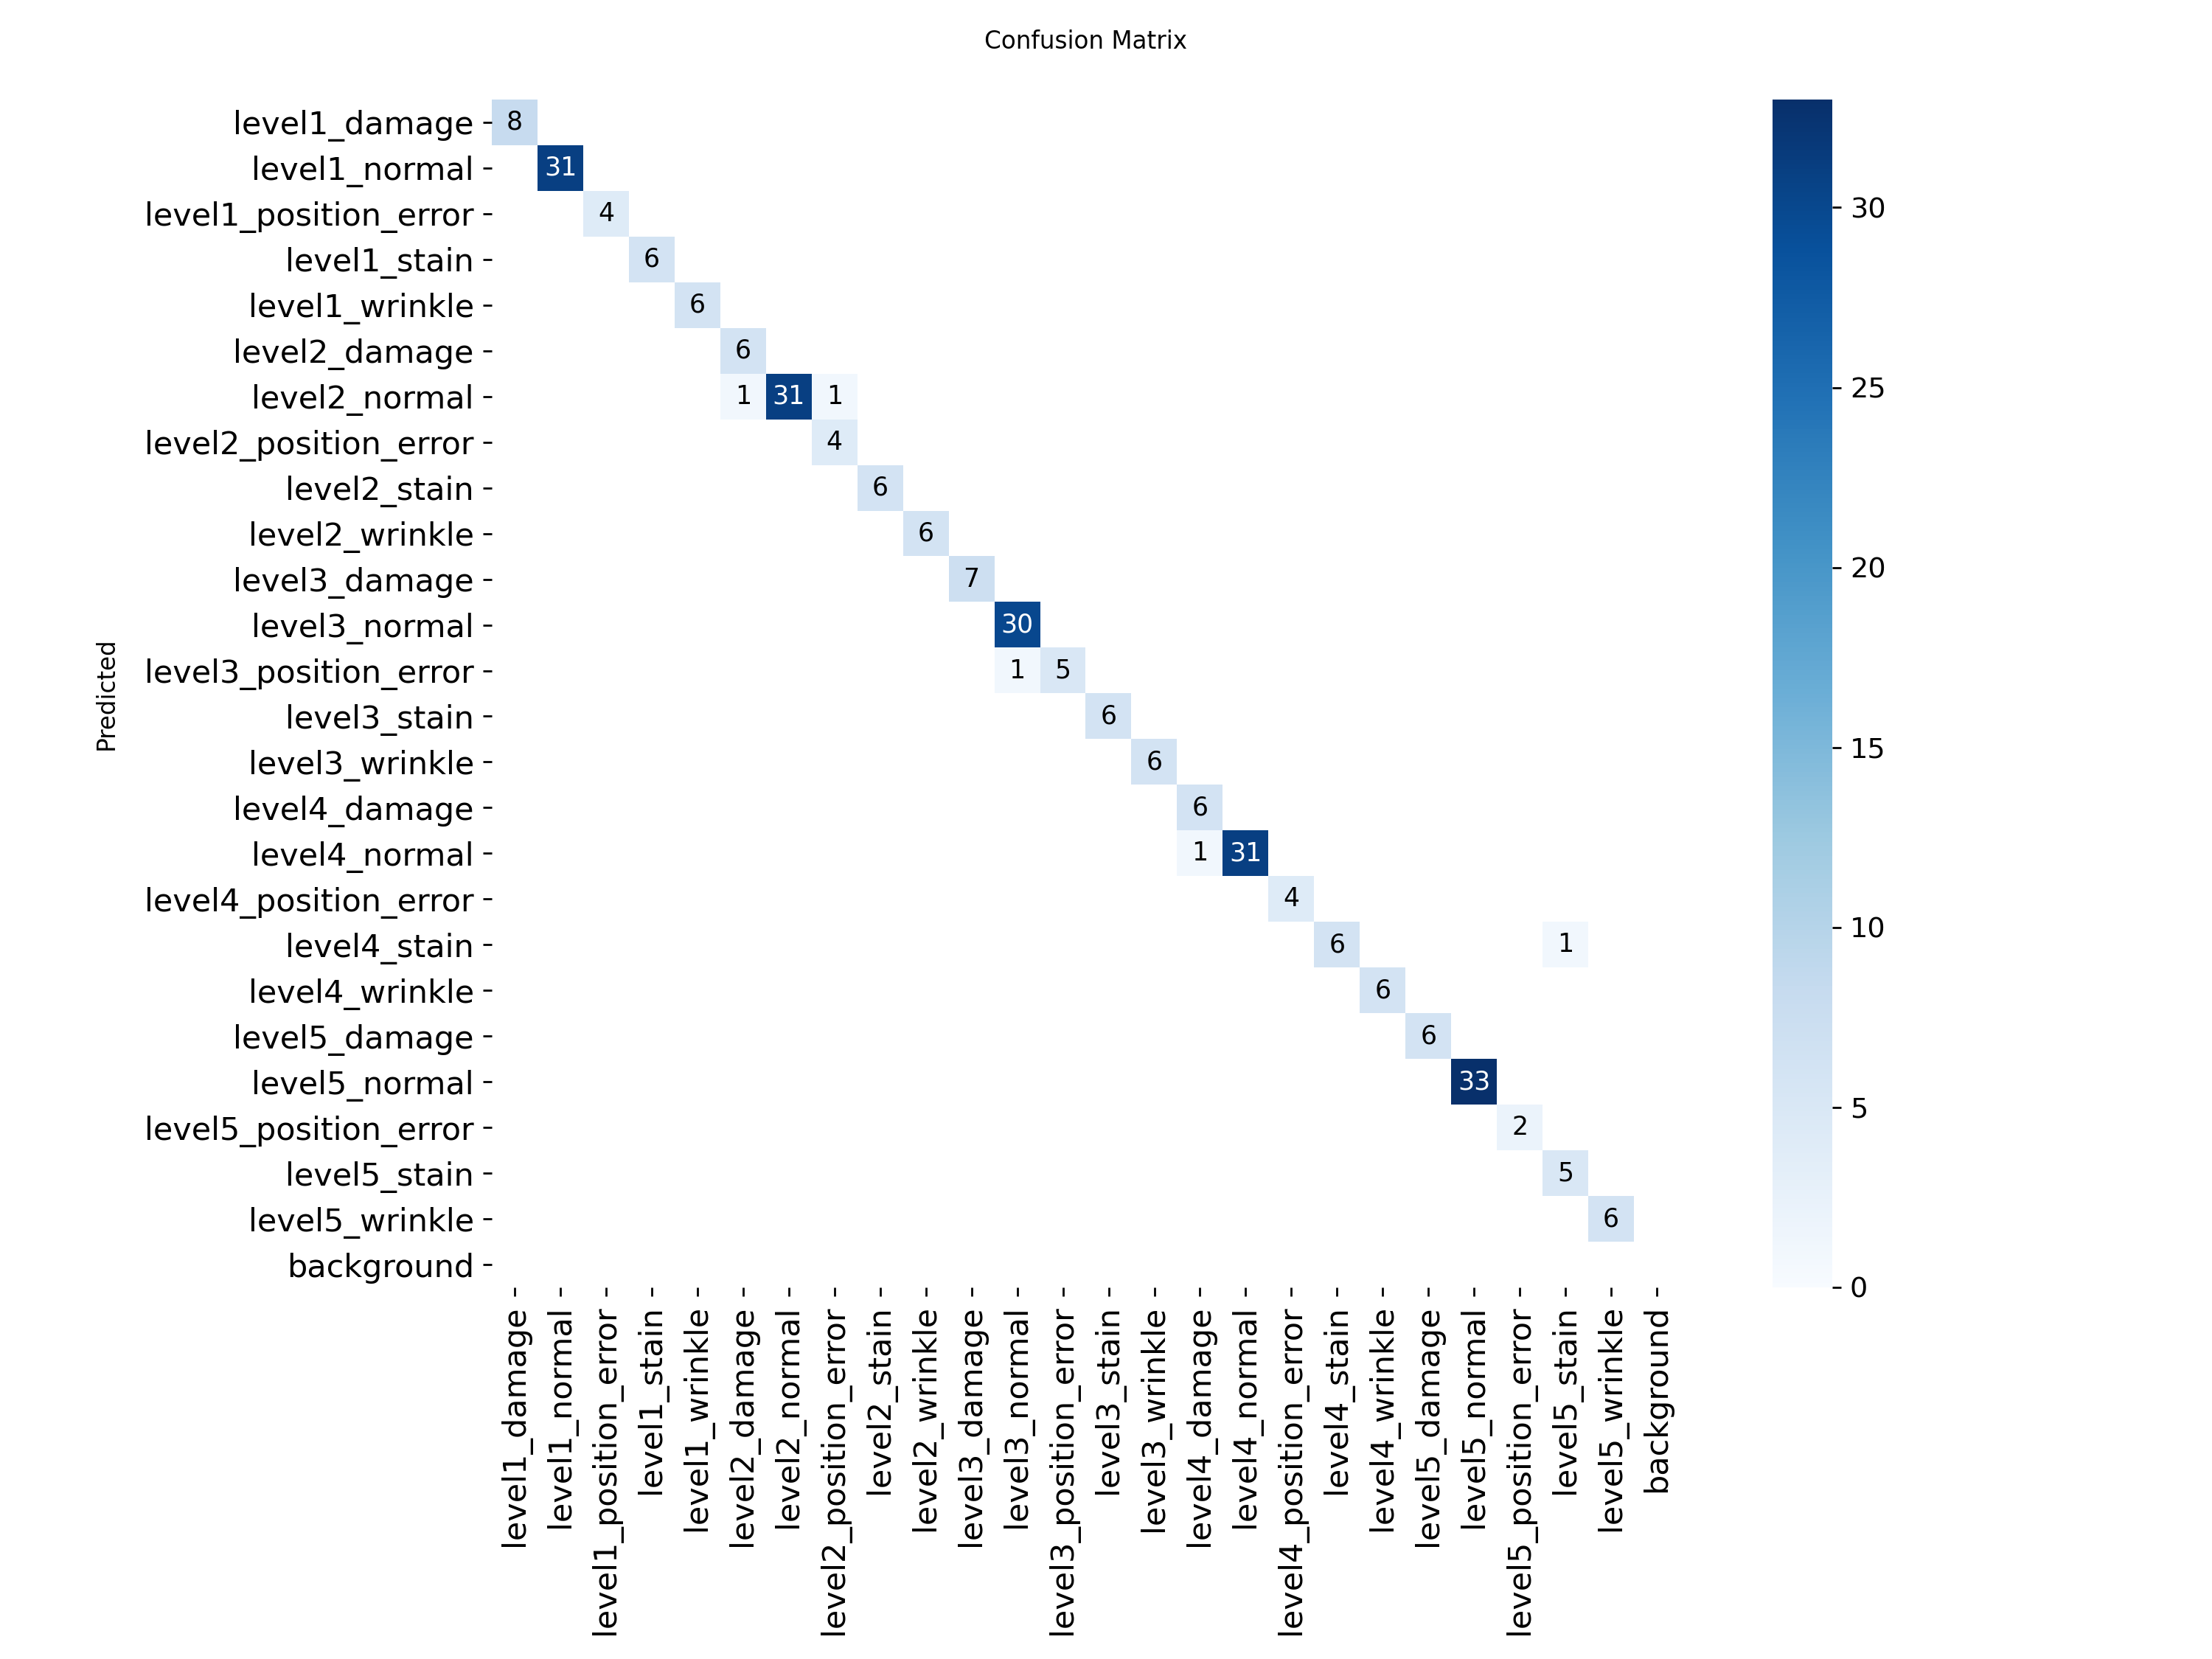

In [ ]:
from IPython.display import Image as IPyImage

# Display the image
IPyImage(filename=f"{os.path.join(results.save_dir, 'confusion_matrix.png')}", width=600)

The `results.png` plot shows the loss and accuracy curves for both training and validation sets over epochs. This is the most important visualization for diagnosing training issues.

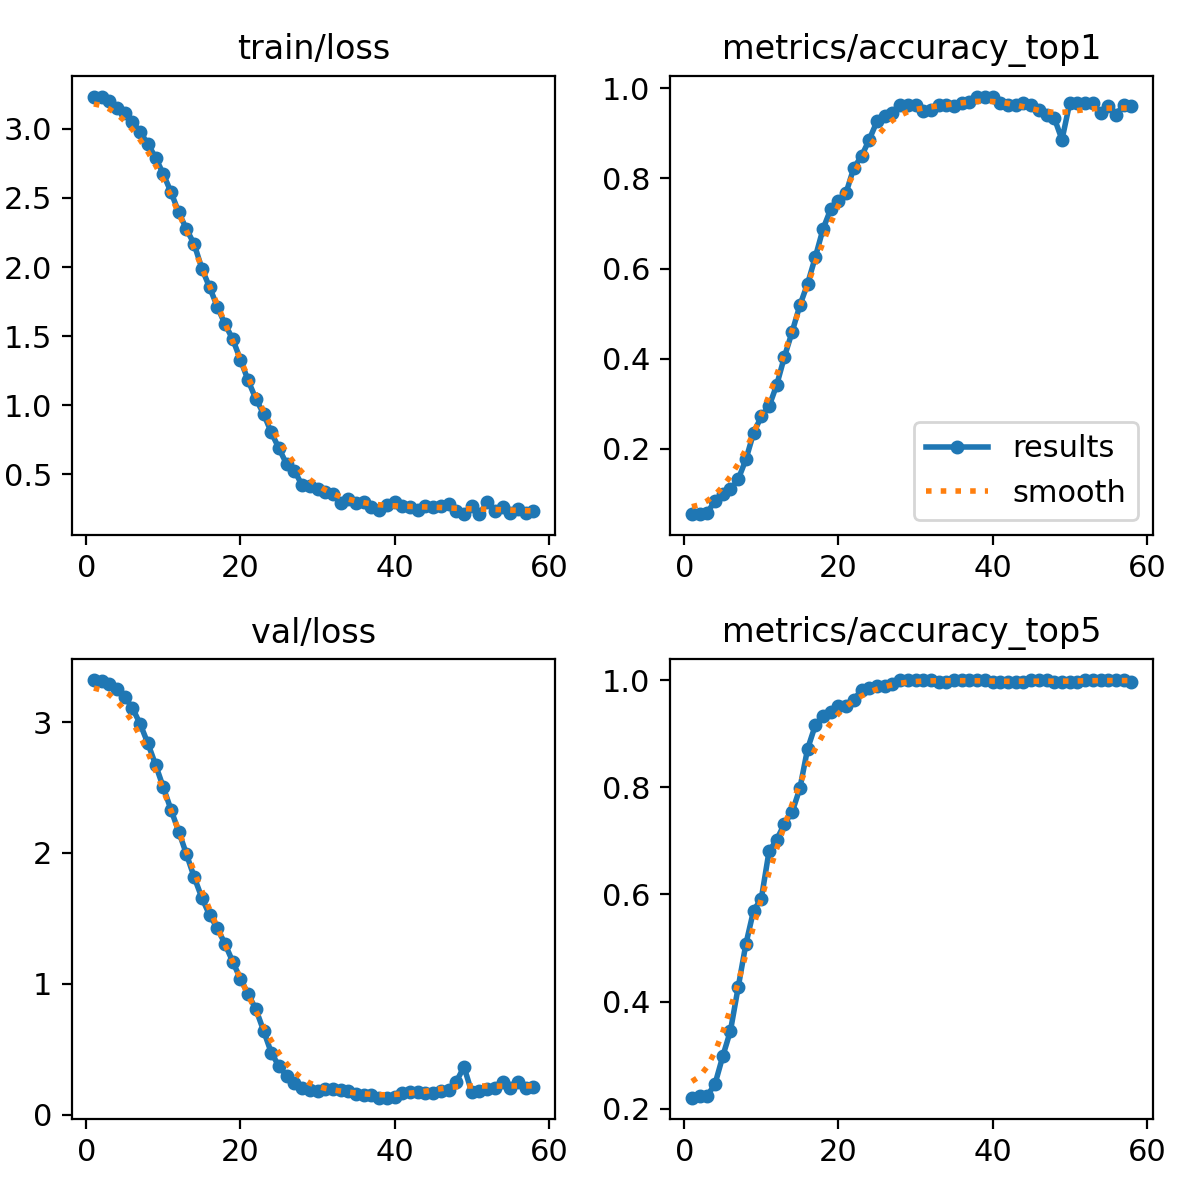

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f"{os.path.join(results.save_dir, 'results.png')}", width=800)

### 6. Model Evaluation on Test Set

We perform an evaluation on the **unseen test set**, this provides the most honest assessment of the model's ability to generalize to new data.

#### Importance of Specialized Metrics

Standard accuracy can be misleading, especially in applications like drowsiness detection where the cost of different errors is not equal.

-   A **False Negative** (classifying a `Drowsy` driver as `Non Drowsy`) is far more dangerous than a **False Positive** (classifying a `Non Drowsy` driver as `Drowsy`).

To capture this, we use these metrics:

-   **APCER (Attack Presentation Classification Error Rate)**: The rate at which `Drowsy` drivers are misclassified as `Non Drowsy`. This is our critical safety metric. **A low APCER is paramount.**

-   **BPCER (Bona Fide Presentation Classification Error Rate)**: The rate at which `Non Drowsy` drivers are misclassified as `Drowsy`. This relates to usability (e.g., false alarms).

-   **ACER (Average Classification Error Rate)**: The average of APCER and BPCER, giving a single score that balances the two types of errors.

In [ ]:
from ultralytics import YOLO
import yaml
import os

def _best_pt(run_dir):
    p = os.path.join(run_dir, "weights", "best.pt")
    if not os.path.exists(p):
        raise FileNotFoundError(f"best.pt not found: {p}")
    return p

def _make_test_yaml(dataset_root, yaml_path):
    train_dir = os.path.join(dataset_root, "train")
    test_dir = os.path.join(dataset_root, "test")
    names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    data_yaml = {"train": train_dir, "val": test_dir, "names": names}
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, allow_unicode=True, sort_keys=False)
    return yaml_path

best_model_path = _best_pt(results.save_dir)
model = YOLO(best_model_path)

test_yaml = _make_test_yaml(DATASET_PATH, os.path.join(HOME, "energy_label_25cls_test.yaml"))

print("Evaluating 25-class model on test set...")
test_results = model.val(
    data=test_yaml,
    project="energy_label_evaluation_25cls",
    name="test_set_eval",
    exist_ok=True,
    split="val"
)

Evaluating 25-class model on test set...
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO11x-cls summary (fused): 94 layers, 28,364,441 parameters, 0 gradients, 110.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.2 ms, read: 53.6±14.5 MB/s, size: 83.0 KB)
val: Scanning /content/drive/MyDrive/dataset0318/test... 169 images, 0 corrupt: 100% ━━━━━━━━━━━━ 169/169 54.5Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 11/11 11.5it/s 1.0s
                   all      0.947      0.994
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/energy_label_evaluation_25cls/test_set_eval


#### Evaluate with Specialized Metrics

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

print("--- Test Set Performance ---")
# The results object contains the top-1 accuracy directly.
accuracy = test_results.top1
print(f"Accuracy: {accuracy:.4f}")

# --- Drowsiness-Specific Metrics ---
print("\n--- Drowsiness Detection Metrics on Test Set ---")

# The confusion matrix is available in the results object.
cm = test_results.confusion_matrix.matrix

# The class names are stored in the model object itself.
class_names = model.names
print(f"Class Names: {class_names}")
print(f"Confusion Matrix:\n{cm}")

drowsy_idx = class_names[0]
nondrowsy_idx = class_names[1]

# Define the integer indices for our classes based on the alphabetical order
# used by the ultralytics trainer.
# class_names[0] would be 'Drowsy', class_names[1] would be 'Non Drowsy'.
drowsy_idx = 0
nondrowsy_idx = 1

# Ensure the confusion matrix has the expected shape before indexing.
if cm.shape[0] < 2 or cm.shape[1] < 2:
    print("\nError: Confusion matrix is smaller than 2x2. Cannot calculate metrics.")
else:
    # APCER (Attack Presentation Classification Error Rate):
    # This is the rate at which 'Drowsy' (the "attack") is misclassified as 'Non Drowsy'.
    # This is a False Negative for the 'Drowsy' class.
    # It's calculated as: (Drowsy samples predicted as Non Drowsy) / (Total actual Drowsy samples)
    drowsy_total = cm[drowsy_idx, :].sum()
    drowsy_misclassified_as_nondrowsy = cm[drowsy_idx, nondrowsy_idx]
    apcer = drowsy_misclassified_as_nondrowsy / drowsy_total if drowsy_total > 0 else 0.0

    # BPCER (Bona Fide Presentation Classification Error Rate):
    # This is the rate at which 'Non Drowsy' (the "bona fide" or normal case) is misclassified as 'Drowsy'.
    # This is a False Positive for the 'Drowsy' class.
    # It's calculated as: (Non Drowsy samples predicted as Drowsy) / (Total actual Non Drowsy samples)
    nondrowsy_total = cm[nondrowsy_idx, :].sum()
    nondrowsy_misclassified_as_drowsy = cm[nondrowsy_idx, drowsy_idx]
    bpcer = nondrowsy_misclassified_as_drowsy / nondrowsy_total if nondrowsy_total > 0 else 0.0

    # ACER: Average of the two error rates.
    acer = (apcer + bpcer) / 2.0

    print(f'\nAPCER (Rate of Drowsy classified as Non Drowsy): {apcer:.4f}')
    print(f'BPCER (Rate of Non Drowsy classified as Drowsy): {bpcer:.4f}')
    print(f'ACER (Average Classification Error Rate): {acer:.4f}')

--- Test Set Performance ---
Accuracy: 0.9467

--- Drowsiness Detection Metrics on Test Set ---
Class Names: {0: 'level1_damage', 1: 'level1_normal', 2: 'level1_position_error', 3: 'level1_stain', 4: 'level1_wrinkle', 5: 'level2_damage', 6: 'level2_normal', 7: 'level2_position_error', 8: 'level2_stain', 9: 'level2_wrinkle', 10: 'level3_damage', 11: 'level3_normal', 12: 'level3_position_error', 13: 'level3_stain', 14: 'level3_wrinkle', 15: 'level4_damage', 16: 'level4_normal', 17: 'level4_position_error', 18: 'level4_stain', 19: 'level4_wrinkle', 20: 'level5_damage', 21: 'level5_normal', 22: 'level5_position_error', 23: 'level5_stain', 24: 'level5_wrinkle'}
Confusion Matrix:
[[          5           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0]
 [

Visualizations provide an intuitive understanding of model performance.

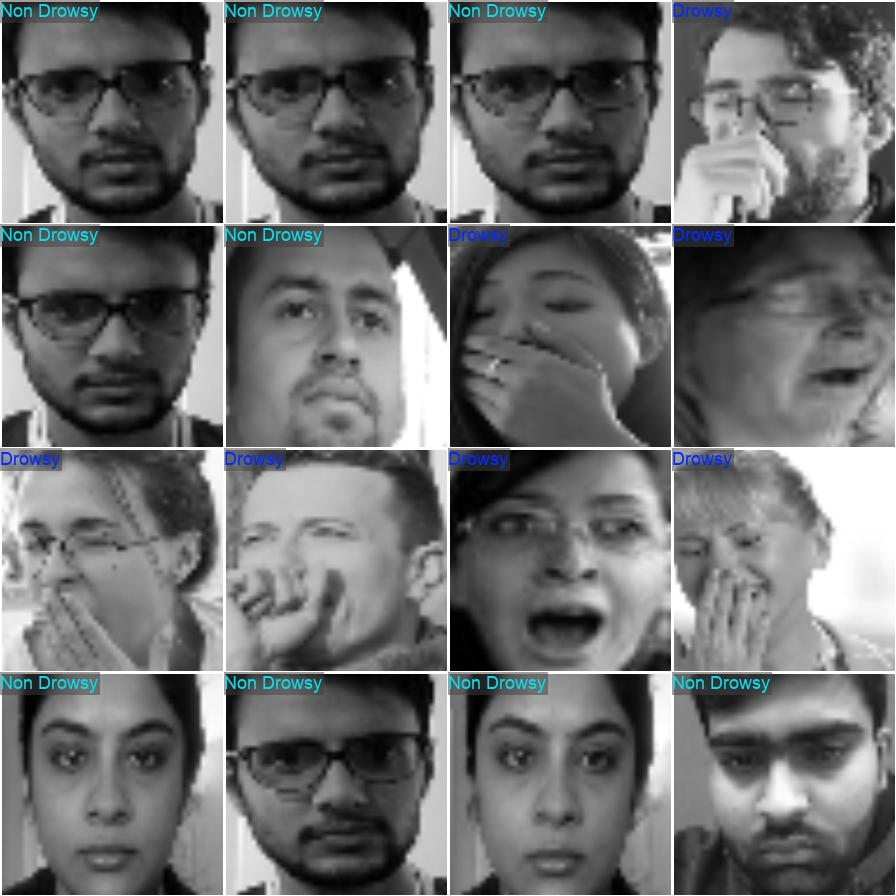

In [ ]:
from IPython.display import Image as IPyImage

eval_path = f"{HOME}/drowsiness_evaluation/test_set_eval"

# Display the image
IPyImage(filename=f"{os.path.join(eval_path, 'val_batch0_pred.jpg')}", width=600)

### 7. Model Explainability with Grad-CAM

This section allows us to understand *why* the model makes certain predictions.

**Gradient-weighted Class Activation Mapping (Grad-CAM)** is a technique that produces a heatmap highlighting the regions in an image that were most influential for the model's decision.

For a drowsiness detector, we expect Grad-CAM to highlight facial features like the eyes, mouth, or head position. This confirms the model is learning relevant patterns and not relying on spurious correlations in the background.

GradCAM produces a heatmap that highlight the regions in the input image that had the most influence on the model's prediction

In [ ]:
import os
import random
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from ultralytics.nn.modules import C2f, C3

def find_last_conv_block(yolo_model):
    """Find the last C2f/C3 layer in model backbone."""
    try:
        backbone = yolo_model.model.model
        conv_blocks = [m for m in backbone if isinstance(m, (C2f, C3))]
        if not conv_blocks:
            print("Error: No C2f or C3 layers found.")
            return None
        return conv_blocks[-1]
    except Exception as e:
        print(f"Could not access target layer: {e}")
        return None

def generate_cam(yolo_model, image_path, target_layer, class_index, save_path, imgsz=224):
    """Generate and save Grad-CAM visualization."""
    pytorch_model = yolo_model.model
    pytorch_model.eval()
    for param in pytorch_model.parameters():
        param.requires_grad_(True)

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not read {image_path}")
        return None

    # Preprocess image
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    normalized_img = np.float32(cv2.resize(img_rgb, (imgsz, imgsz))) / 255.0
    input_tensor = torch.from_numpy(normalized_img.transpose(2, 0, 1)).unsqueeze(0).to(yolo_model.device)

    # Generate CAM
    with GradCAM(model=pytorch_model, target_layers=[target_layer]) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(class_index)])[0, :]

    # Get prediction
    with torch.no_grad():
        model_output = pytorch_model(input_tensor)
    logits = model_output[0] if isinstance(model_output, tuple) else model_output
    probs = torch.nn.functional.softmax(logits, dim=-1)
    pred, pred_class_idx = torch.max(probs, dim=-1)

    # Create visualization
    visualization = show_cam_on_image(normalized_img, grayscale_cam, use_rgb=True)

    # Plot and save
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Grad-CAM for Target Class: '{yolo_model.names[class_index]}'", fontsize=16)

    ax1.imshow(normalized_img)
    ax1.set_title("Original Image")
    ax1.axis('off')

    ax2.imshow(visualization)
    ax2.set_title(f"Prediction: {yolo_model.names[pred_class_idx.item()]}")
    ax2.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)

    return save_path


# Main execution
print("Running Grad-CAM on test samples...")

os.makedirs(VISUALIZATION_PATH, exist_ok=True)

target_layer = find_last_conv_block(model)

# Get class indices
try:
    class_map_inv = {v: k for k, v in model.names.items()}
    drowsy_idx, nondrowsy_idx = class_map_inv['Drowsy'], class_map_inv['Non Drowsy']
except (AttributeError, KeyError):
    print("Using default class indices: Drowsy=0, Non Drowsy=1")
    drowsy_idx, nondrowsy_idx = 0, 1

generated_paths = []

# Process samples from both classes
for class_name, class_idx in [('Drowsy', drowsy_idx), ('Non Drowsy', nondrowsy_idx)]:
    class_dir = os.path.join(test_dir, class_name)
    if os.path.isdir(class_dir):
        files = [f for f in os.listdir(class_dir) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
        random_files = random.sample(files, min(2, len(files)))  # Randomly select up to 2 files
        for img_file in random_files:
            img_path = os.path.join(class_dir, img_file)
            base_name = os.path.splitext(img_file)[0]
            save_path = os.path.join(VISUALIZATION_PATH, f"grad_cam_{base_name}_{class_name.lower().replace(' ', '')}.png")

            result = generate_cam(model, img_path, target_layer, class_idx, save_path)
            if result:
                generated_paths.append(result)

print(f"Generated {len(generated_paths)} CAM images in {os.path.abspath(VISUALIZATION_PATH)}")
print(f"GradCAM images: {generated_paths}")

Running Grad-CAM on test samples...
Generated 4 CAM images in /workspace/visualizations
GradCAM images: ['/workspace/visualizations/grad_cam_yashar_test_622_0223_drowsy.png', '/workspace/visualizations/grad_cam_yashar_test_379.jpg_0_0490_drowsy.png', '/workspace/visualizations/grad_cam_yashar_test_w0075_0662_nondrowsy.png', '/workspace/visualizations/grad_cam_yashar_test_zc0021_0164_nondrowsy.png']


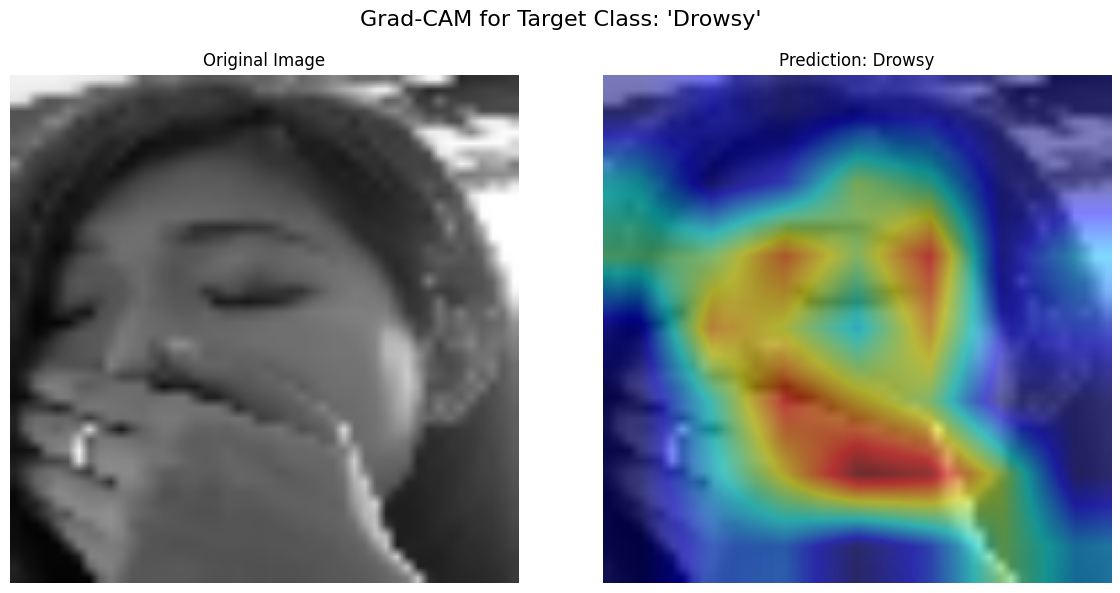

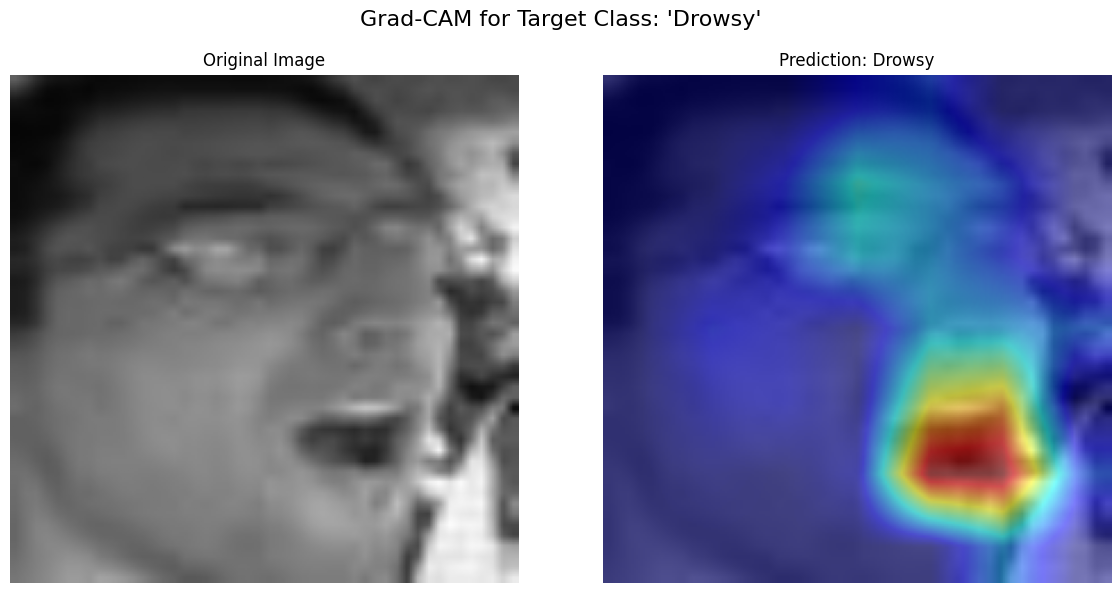

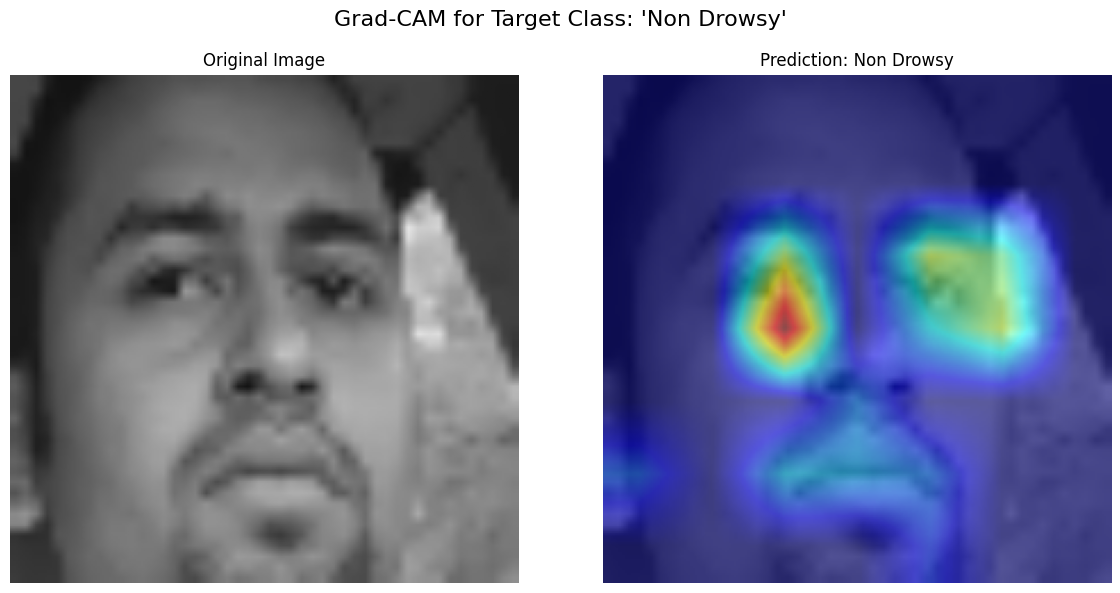

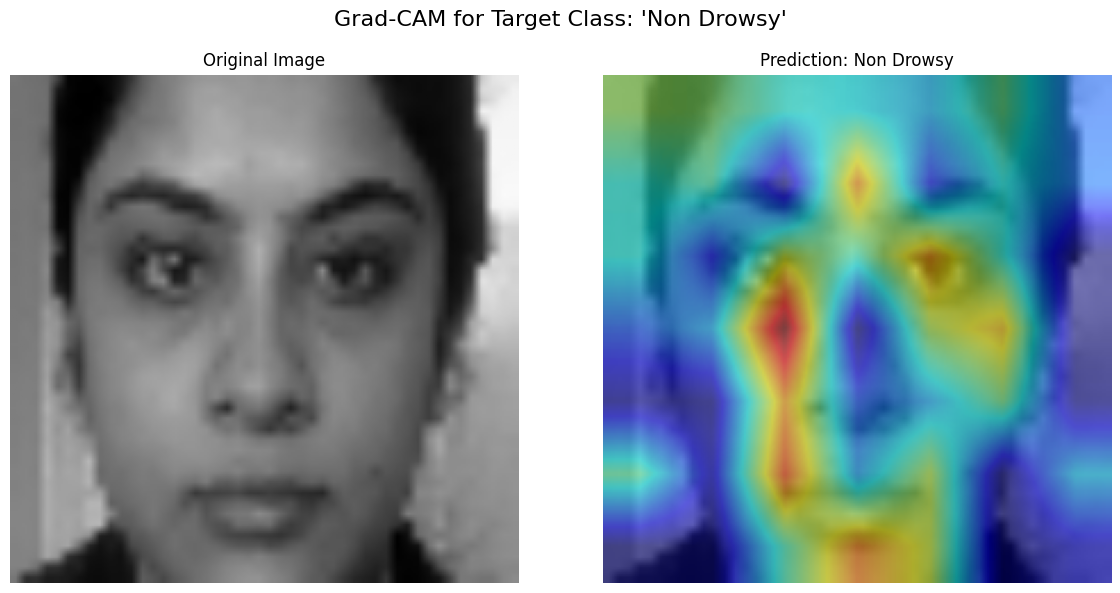

In [ ]:
from IPython.display import Image as IPyImage

# Display the grad_cam images
for image_path in generated_paths:
    display(IPyImage(filename=image_path, width=600))

The heat maps demonstrate the model's focus on eye-closure, yawning, and head pose.

2.8 Following Steps: 推理输出 + 位置判定 + OCR 与产品型号比对

你要的最终输出不是单纯分类结果，还需要： + OCR 与产品型号比对

- 位置检测：若预测类别名形如 `levelX_position_error`，则判定“位置不合规”
- 识别标签数据信息并与预设产品型号比对：需要 OCR（文字识别）

你需要根据真实业务把 `expected = {"model": "YOUR_PRODUCT_MODEL"}` 换成你的“预设产品型号信息”（例如从数据库/Excel/接口读入）。

In [ ]:
import os
from pathlib import Path

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def _maybe_ocr_text(image_path):
    try:
        import easyocr
        reader = easyocr.Reader(["ch_sim", "en"], gpu=False)
        res = reader.readtext(str(image_path), detail=0)
        return "\n".join(res)
    except Exception:
        pass

    try:
        import pytesseract
        import cv2
        img = cv2.imread(str(image_path))
        if img is None:
            return ""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU | cv2.THRESH_BINARY)[1]
        return pytesseract.image_to_string(gray, lang="chi_sim+eng")
    except Exception:
        return ""

def _predict_top1(yolo_model, image_path):
    pred = yolo_model.predict(source=str(image_path), verbose=False)
    if not pred:
        return None
    p = pred[0]
    probs = getattr(p, "probs", None)
    if probs is None:
        return None
    top1 = int(probs.top1)
    conf = float(probs.top1conf)
    name = yolo_model.names[top1] if isinstance(yolo_model.names, dict) else yolo_model.names[top1]
    return {"class_id": top1, "class_name": name, "conf": conf}

def compare_with_expected(ocr_text, expected):
    text = (ocr_text or "").upper()
    mismatches = []

    model_expected = expected.get("model")
    if model_expected:
        ok = model_expected.upper() in text
        if not ok:
            mismatches.append({"field": "model", "expected": model_expected, "found": None})

    return {"ok": len(mismatches) == 0, "mismatches": mismatches}

def _parse_level_defect(class_name):
    name = (class_name or "").lower().strip()
    parts = name.split("_", 1)
    if len(parts) != 2:
        return None, None

    level_part, defect = parts[0], parts[1]
    if not level_part.startswith("level"):
        return None, None

    try:
        level = int(level_part.replace("level", ""))
    except Exception:
        return None, None

    return level, defect


def predict_energy_label(image_path, model, expected_product=None):
    image_path = Path(image_path)

    cls_pred = _predict_top1(model, image_path)
    level, defect = _parse_level_defect(cls_pred["class_name"] if cls_pred else None)

    ocr_text = _maybe_ocr_text(image_path)

    out = {
        "image": str(image_path),
        "pred_25cls": cls_pred,
        "energy_level": level,
        "defect": defect,
        "position_ok": (defect != "position_error") if defect is not None else None,
        "ocr_text": ocr_text,
    }

    if expected_product is not None:
        out["compare"] = compare_with_expected(ocr_text, expected_product)

    return out


sample_dir = Path(RAW_DATASET_PATH) / "test"
sample_images = [p for p in sample_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS]

if sample_images:
    img = sample_images[0]
    expected = {"model": "YOUR_PRODUCT_MODEL"}
    pred = predict_energy_label(img, model, expected_product=expected)
    pred
else:
    print("No test images found under:", sample_dir)